# PB2002 Plate-Based Mainshock Analysis

This notebook assigns each shallow M>6 mainshock to a PB2002 tectonic plate using polygon containment from `tectonicplates-master`, rather than broad latitude/longitude boxes. Plate groups with fewer than 10 mainshocks are merged into `Other`.

In [1]:
from pathlib import Path
import os
import pandas as pd
from IPython.display import Image, display

ROOT = Path('/Users/xusi/phdstudy/code/Prediction_contest')
OUT = ROOT / 'outputs/plate_mainshock_analysis'
OUT.mkdir(parents=True, exist_ok=True)

os.environ.setdefault('MPLCONFIGDIR', str(OUT / '.mplconfig'))
(OUT / '.mplconfig').mkdir(parents=True, exist_ok=True)

from plate_mainshock_analysis import (
    MAINSHOCK_TABLE,
    PLATES_GEOJSON,
    BOUNDARIES_GEOJSON,
    run_analysis,
)

print('mainshock table:', MAINSHOCK_TABLE)
print('plates:', PLATES_GEOJSON)
print('boundaries:', BOUNDARIES_GEOJSON)
print('output:', OUT)

mainshock table: /Users/xusi/phdstudy/code/Prediction_contest/outputs/shallow_regional_analysis/shallow_mainshock_aftershock_windows_depth_le_70_r200.parquet
plates: /Users/xusi/phdstudy/code/Prediction_contest/tectonicplates-master/GeoJSON/PB2002_plates.json
boundaries: /Users/xusi/phdstudy/code/Prediction_contest/tectonicplates-master/GeoJSON/PB2002_boundaries.json
output: /Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis


## Method

- Input mainshocks: the current shallow M>6 mainshock table (`depth <= 70 km`).
- Plate model: PB2002 plate polygons from `tectonicplates-master/GeoJSON/PB2002_plates.json`.
- Assignment: convert mainshock epicenters to point geometries and spatially join them to plate polygons.
- Rare groups: raw plates with fewer than 30 mainshocks are grouped as `Other`.
- T-window statistics: for each plate group and T1/T2/T3, summarize aftershock `delta_hours` and `ΔM = M_aftershock - M_mainshock`.
- Mapping: PyGMT Pacific-centered world map with PB2002 boundaries and mainshock points colored by plate group.

In [2]:
results = run_analysis(output_dir=OUT, min_count=30)
assigned = results['assigned']
counts = results['counts']
twindow_summary = results['twindow_summary']
metadata = results['metadata']

metadata

{'mainshock_table': '/Users/xusi/phdstudy/code/Prediction_contest/outputs/shallow_regional_analysis/shallow_mainshock_aftershock_windows_depth_le_70_r200.parquet',
 'plates_geojson': '/Users/xusi/phdstudy/code/Prediction_contest/tectonicplates-master/GeoJSON/PB2002_plates.json',
 'boundaries_geojson': '/Users/xusi/phdstudy/code/Prediction_contest/tectonicplates-master/GeoJSON/PB2002_boundaries.json',
 'min_count_for_named_plate_group': 30,
 'mainshock_rows': 2388,
 'raw_plate_count': 50,
 'grouped_plate_count': 21,
 'other_rows': 363,
 'assigned_parquet': '/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/mainshock_plate_assignments_depth_le_70_min30.parquet',
 'assigned_csv': '/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/mainshock_plate_assignments_depth_le_70_min30.csv',
 'counts_csv': '/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/mainshock_plate_group_counts_depth_le_70_min30.csv',
 'raw_co

## Plate Group Counts

In [3]:
counts

,plate_group,mainshock_count,is_other
0,Other,363,True
1,Pacific,237,False
2,Okhotsk,205,False
3,Sunda,195,False
4,North America,188,False
5,South America,160,False
6,Eurasia,131,False
7,New Hebrides,119,False
8,Antarctica,112,False
9,Australia,97,False


## T1/T2/T3 Delta Summary By Plate

For each plate group, this table summarizes the delay time and magnitude difference of the maximum aftershock selected in each Tianchi window.

In [4]:
twindow_summary

,plate_group,window,mainshock_count,target_count,target_coverage_pct,delay_mean_h,delay_median_h,delay_q25_h,delay_q75_h,mag_delta_mean,mag_delta_median,mag_delta_q25,mag_delta_q75,mag_delta_min,mag_delta_max
0,Other,T1,363,291,80.165289,5.811688,3.125217,0.533781,9.818361,-1.401581,-1.4,-1.900,-1.100,-6.3,1.4
1,Other,T2,363,227,62.534435,43.903763,40.834008,31.987488,54.388293,-1.753524,-1.8,-2.200,-1.300,-6.6,0.8
2,Other,T3,363,217,59.779614,112.519129,107.428284,86.887947,132.058839,-1.729217,-1.8,-2.100,-1.300,-3.3,0.1
3,Pacific,T1,237,194,81.856540,6.623840,3.556542,0.623562,12.057015,-1.130876,-1.3,-1.800,-0.600,-3.0,1.5
4,Pacific,T2,237,179,75.527426,45.524761,43.755067,33.360035,56.407275,-1.441508,-1.5,-2.000,-0.900,-6.2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,Banda Sea,T2,33,25,75.757576,42.544097,43.862661,32.354961,55.400508,-1.668000,-1.6,-2.000,-1.400,-2.7,-0.6
59,Banda Sea,T3,33,21,63.636364,116.526377,111.402858,90.692160,142.012725,-1.719048,-1.7,-2.000,-1.500,-2.6,-0.9
60,Sandwich,T1,30,25,83.333333,7.055922,6.590647,0.305978,12.766350,-0.984000,-1.0,-1.400,-0.700,-1.8,0.6
61,Sandwich,T2,30,23,76.666667,34.532934,30.923411,25.513622,39.349486,-1.304348,-1.3,-1.750,-0.800,-2.6,-0.1


## T-Window Delay And ΔM Figures

/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/plate_twindow_delay_boxplots_depth_le_70_min30.png


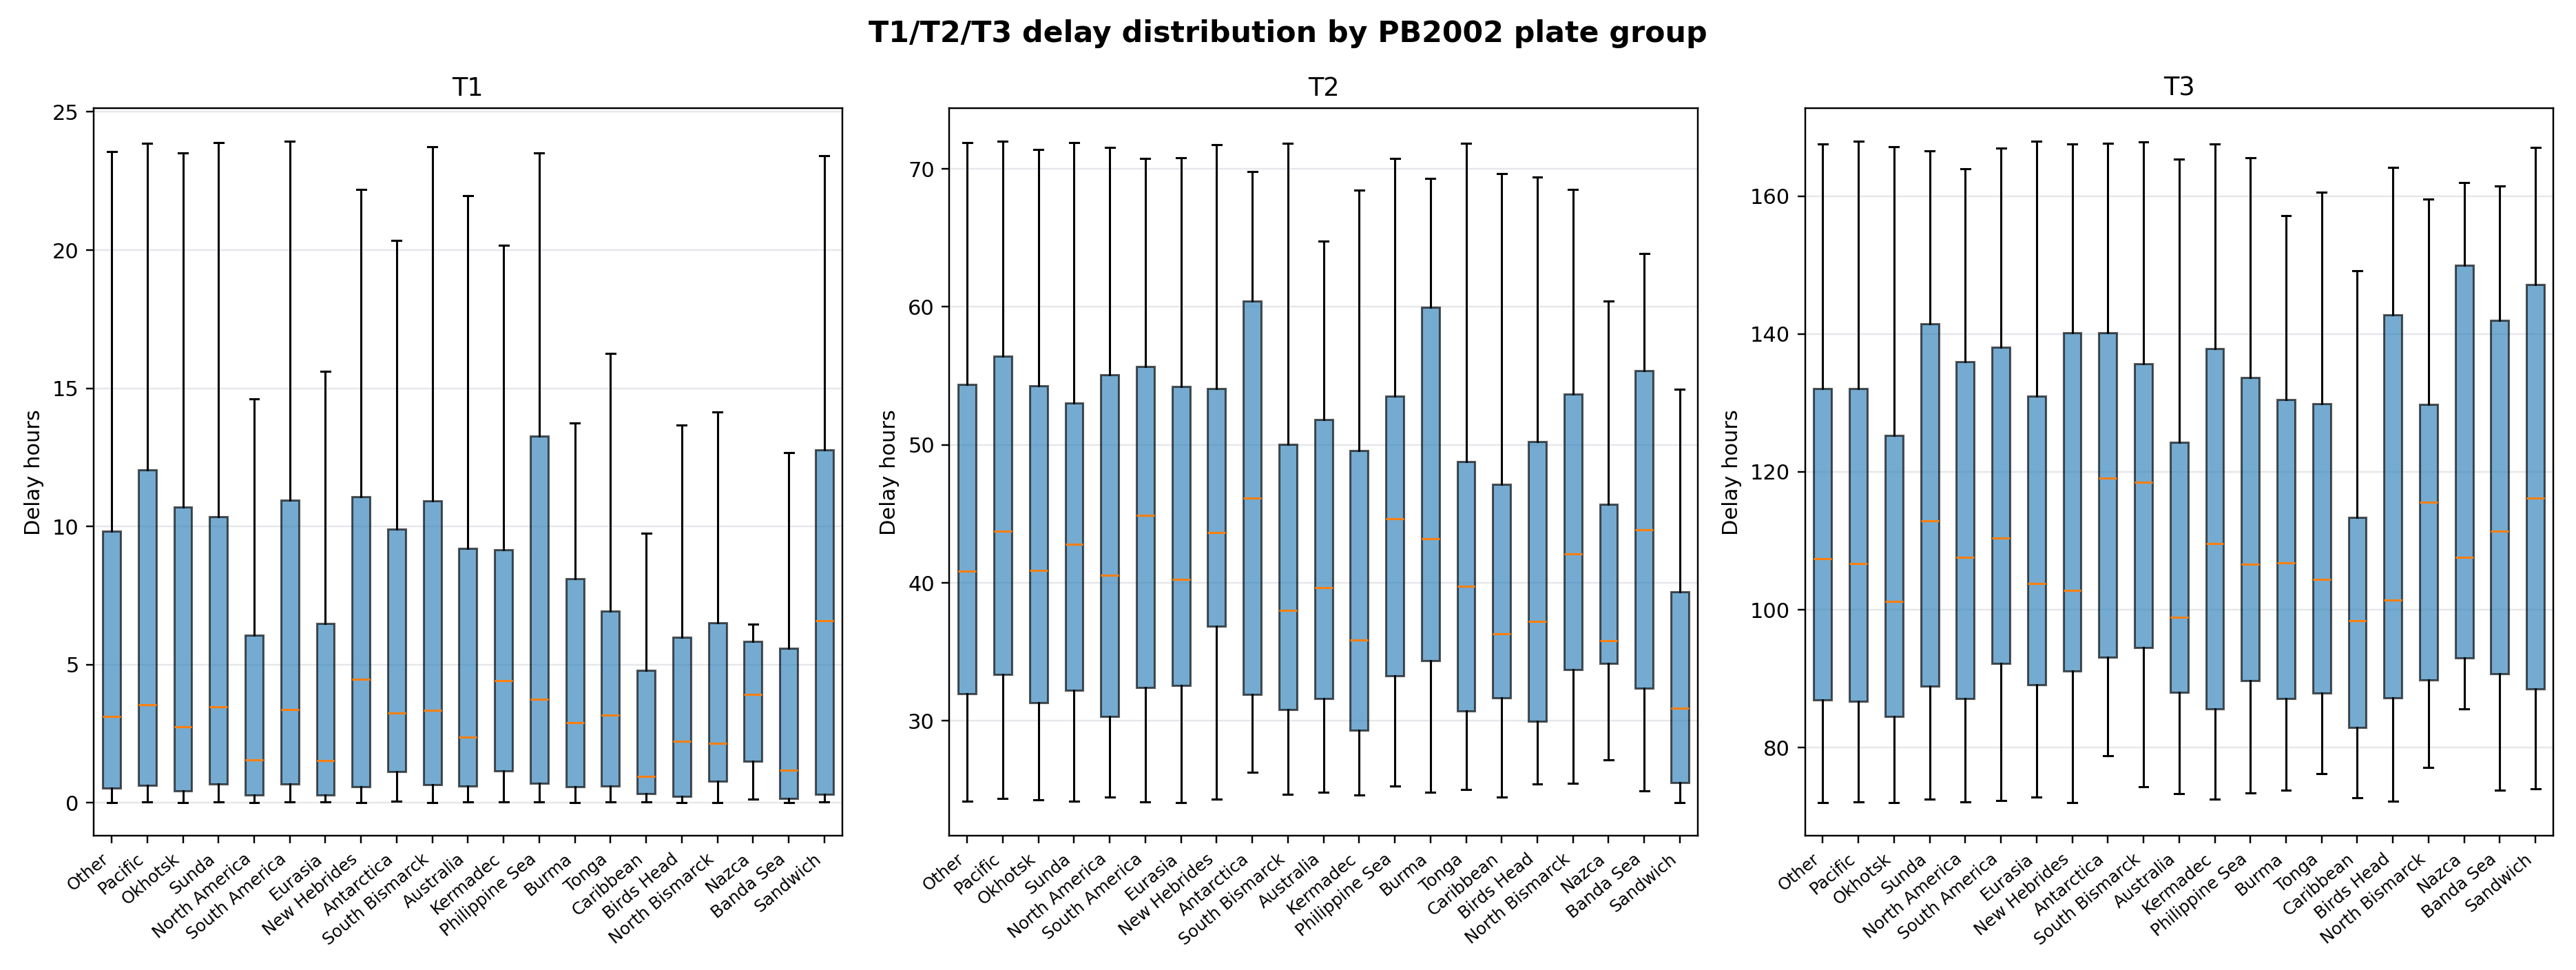

/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/plate_twindow_mag_delta_boxplots_depth_le_70_min30.png


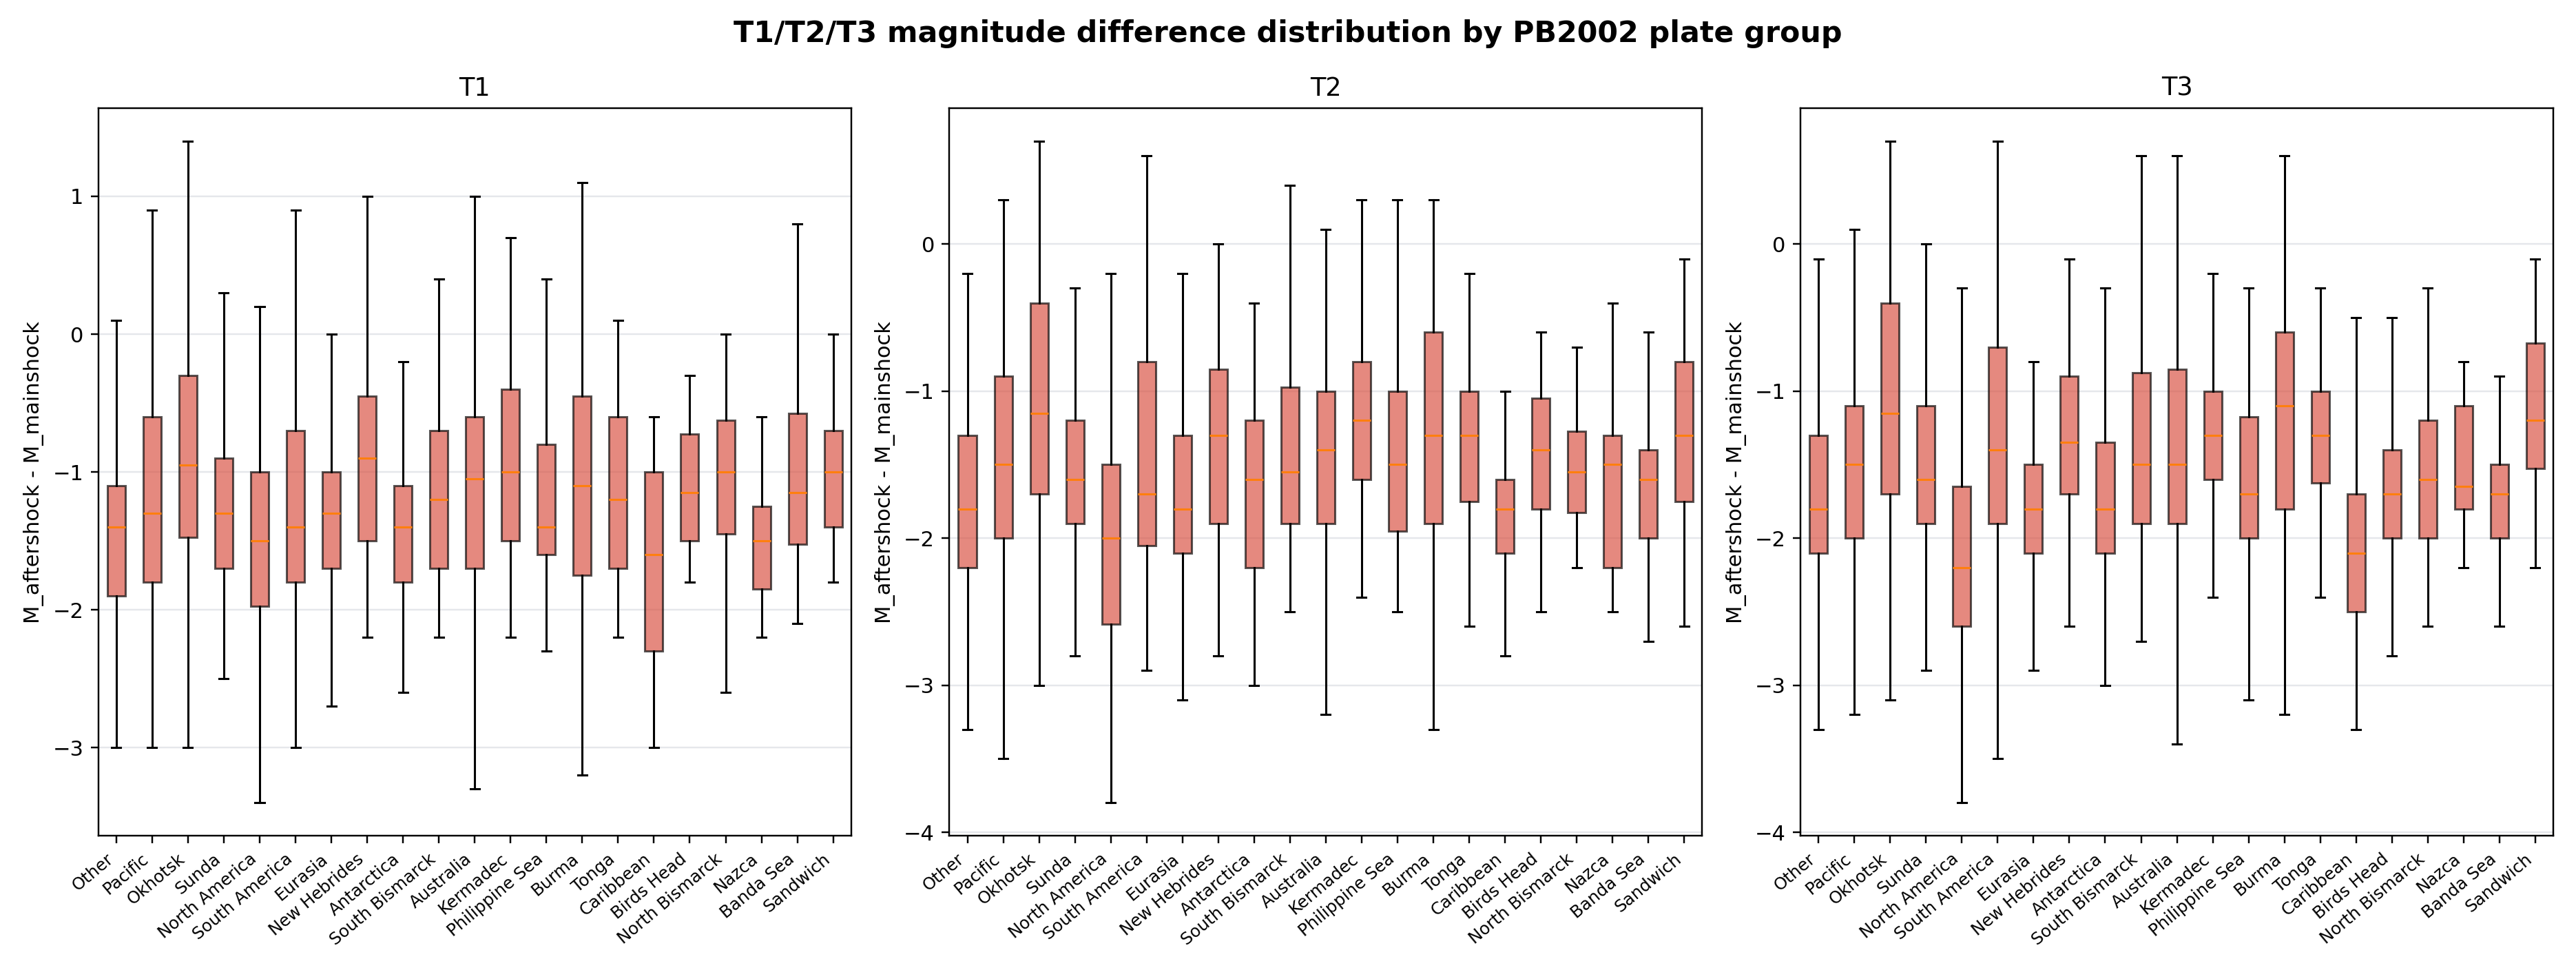

/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/plate_twindow_delay_median_heatmap_depth_le_70_min30.png


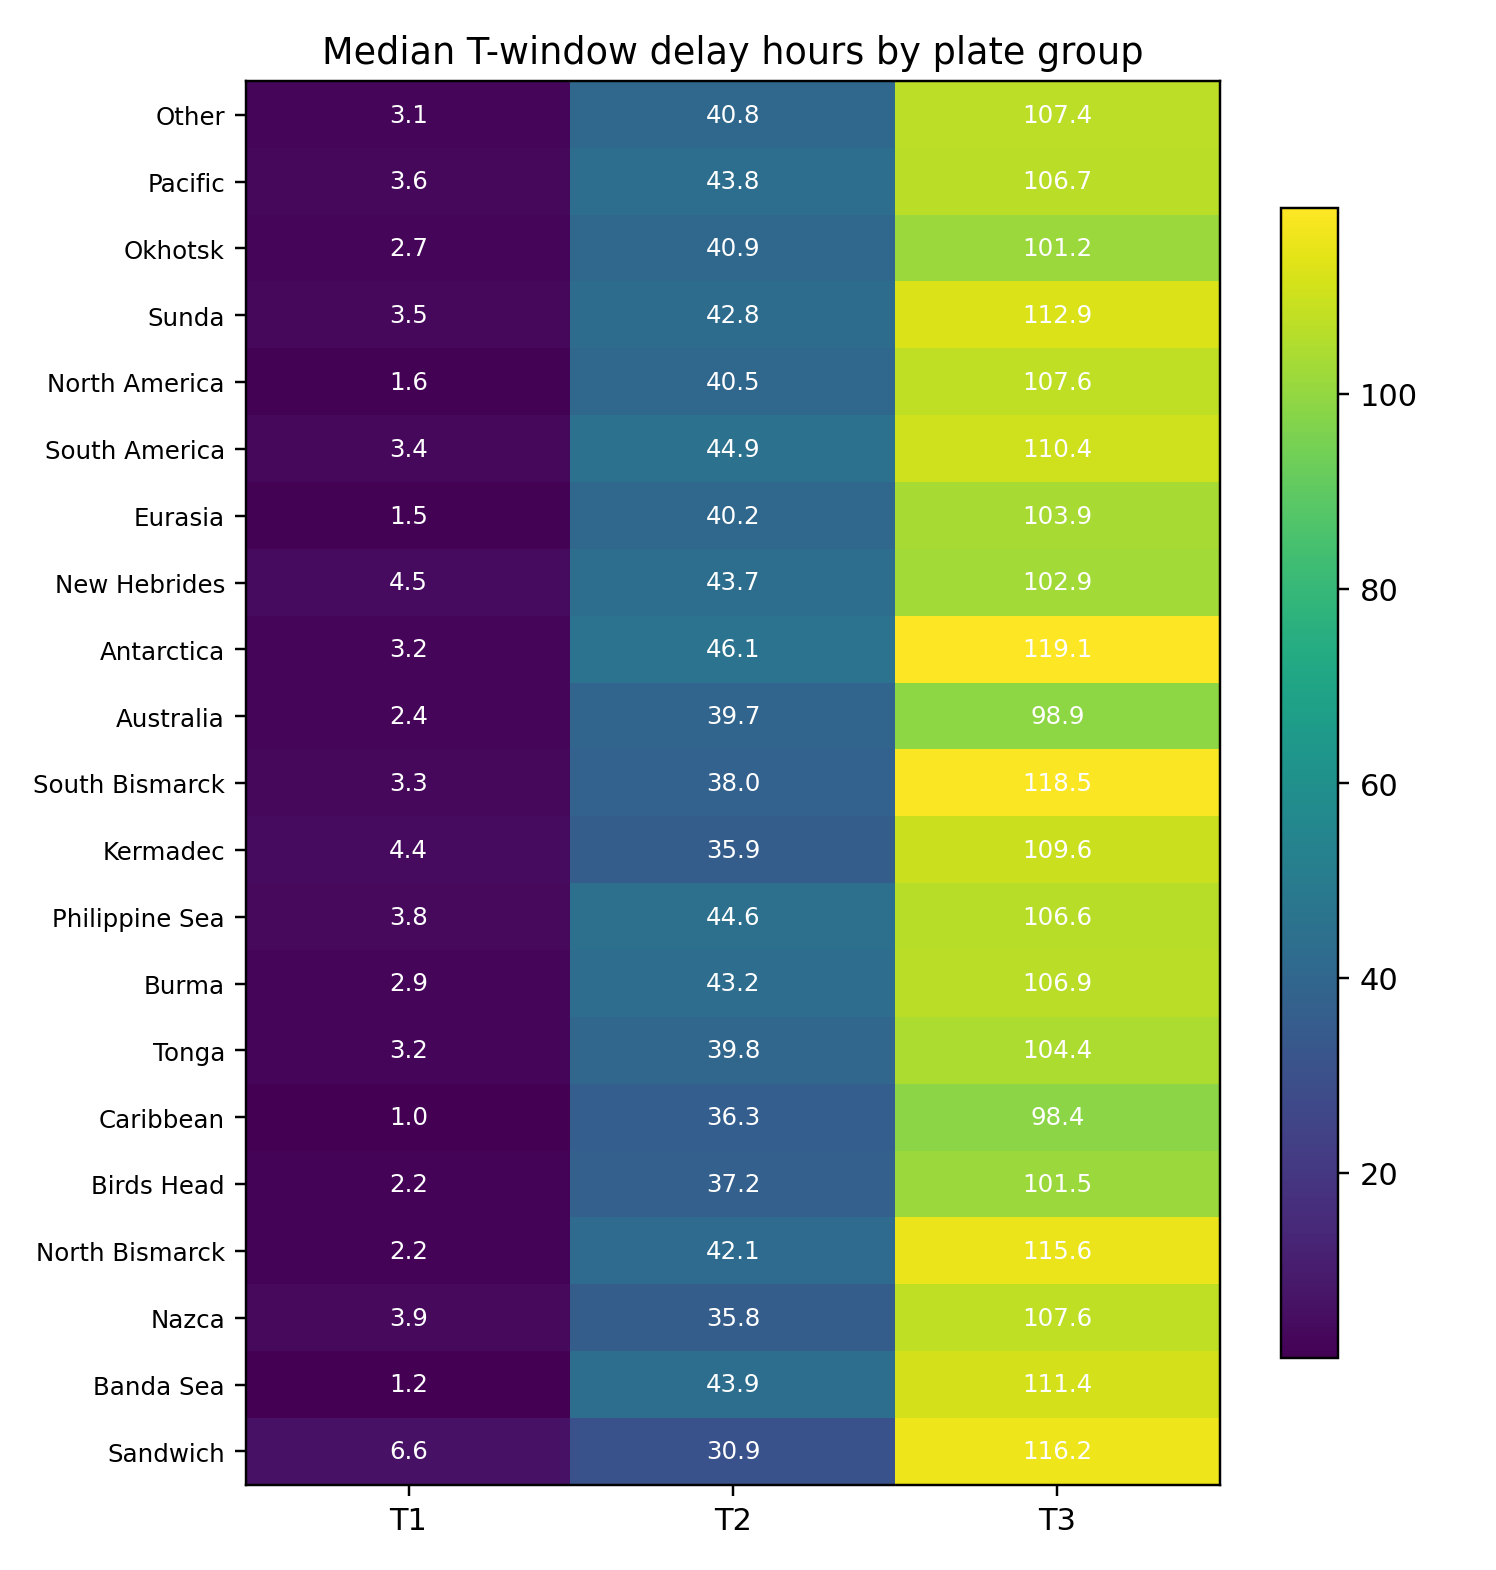

/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/plate_twindow_mag_delta_median_heatmap_depth_le_70_min30.png


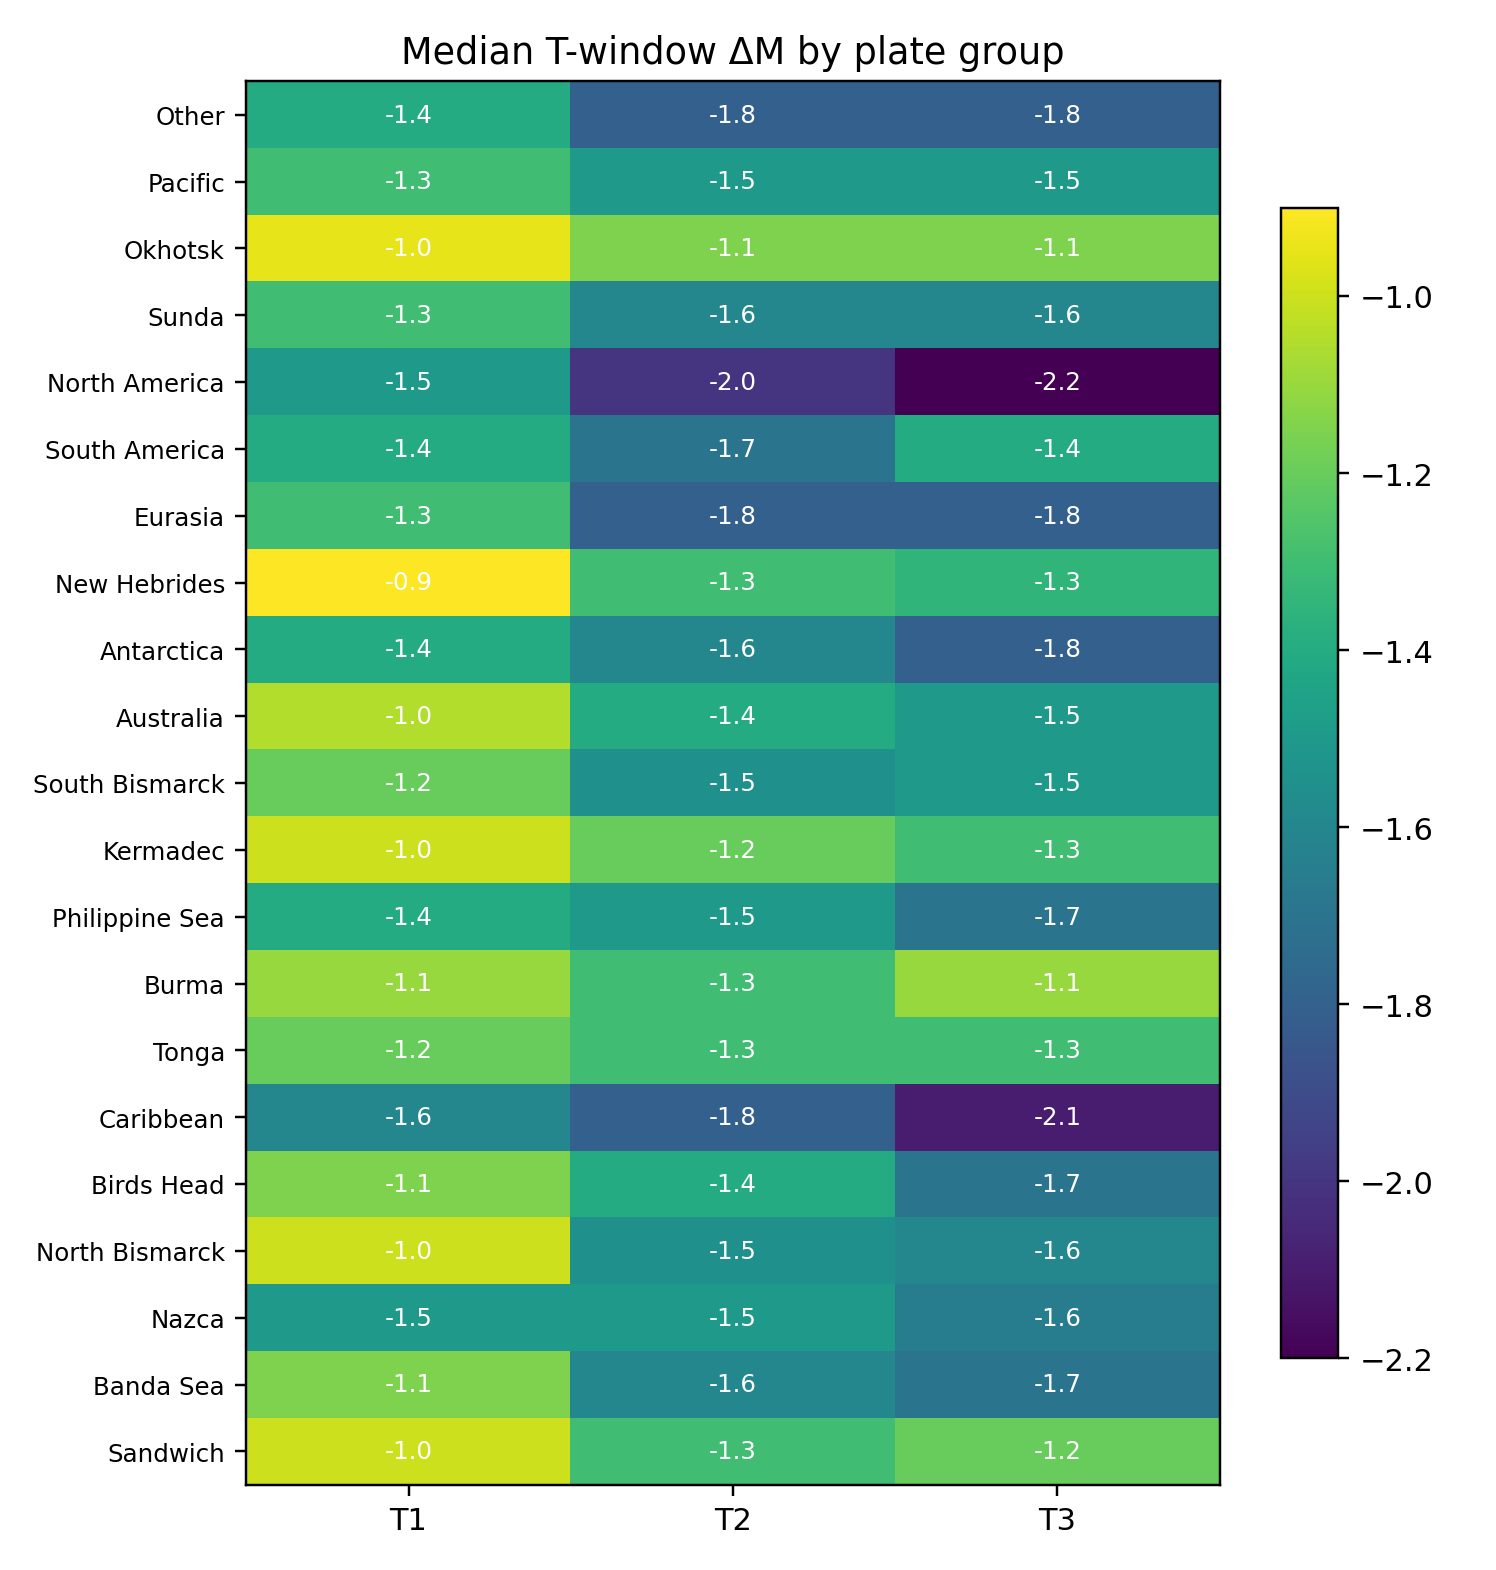

In [5]:
for key in ['delay_boxplot_png', 'mag_delta_boxplot_png', 'delay_heatmap_png', 'mag_delta_heatmap_png']:
    path = Path(metadata[key])
    print(path)
    display(Image(filename=str(path)))

## Assignment Table Preview

In [6]:
preview_cols = [
    'mainshock_id', 'mainshock_time_utc', 'mainshock_latitude', 'mainshock_longitude',
    'mainshock_depth_km', 'mainshock_mag', 'plate_code', 'plate_name', 'plate_group'
]
assigned[preview_cols].head(20)

,mainshock_id,mainshock_time_utc,mainshock_latitude,mainshock_longitude,mainshock_depth_km,mainshock_mag,plate_code,plate_name,plate_group
0,usp0009ks4,2000-01-05 07:40:40.730000+00:00,-11.371,165.378,33.0,6.1,PA,Pacific,Pacific
1,usp0009ktq,2000-01-06 10:42:25+00:00,58.040,-136.870,1.0,6.1,PA,Pacific,Pacific
2,usp0009kub,2000-01-06 21:31:06.220000+00:00,16.095,119.484,33.0,6.2,SU,Sunda,Sunda
3,usp0009kvr,2000-01-08 01:19:46.660000+00:00,-9.805,159.811,33.0,6.4,PA,Pacific,Pacific
4,usp0009kwj,2000-01-08 11:59:21.840000+00:00,-23.169,-70.122,36.0,6.4,SA,South America,South America
5,usp0009kz2,2000-01-09 21:54:40.490000+00:00,-18.823,174.370,33.0,6.5,CR,Conway Reef,Other
6,usp0009mdh,2000-01-20 09:41:47.340000+00:00,43.649,-127.257,10.0,6.1,JF,Juan de Fuca,Other
7,usp0009mps,2000-01-26 13:26:50+00:00,-17.272,-174.002,33.0,6.3,TO,Tonga,Tonga
8,usp0009msf,2000-01-28 14:21:07.340000+00:00,43.046,146.837,61.1,6.8,OK,Okhotsk,Okhotsk
9,usp0009n4c,2000-02-06 11:33:52.280000+00:00,-5.844,150.876,33.0,6.6,SB,South Bismarck,South Bismarck


## Plate-Based Map

/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/pygmt_mainshock_plate_groups_depth_le_70_min30.png


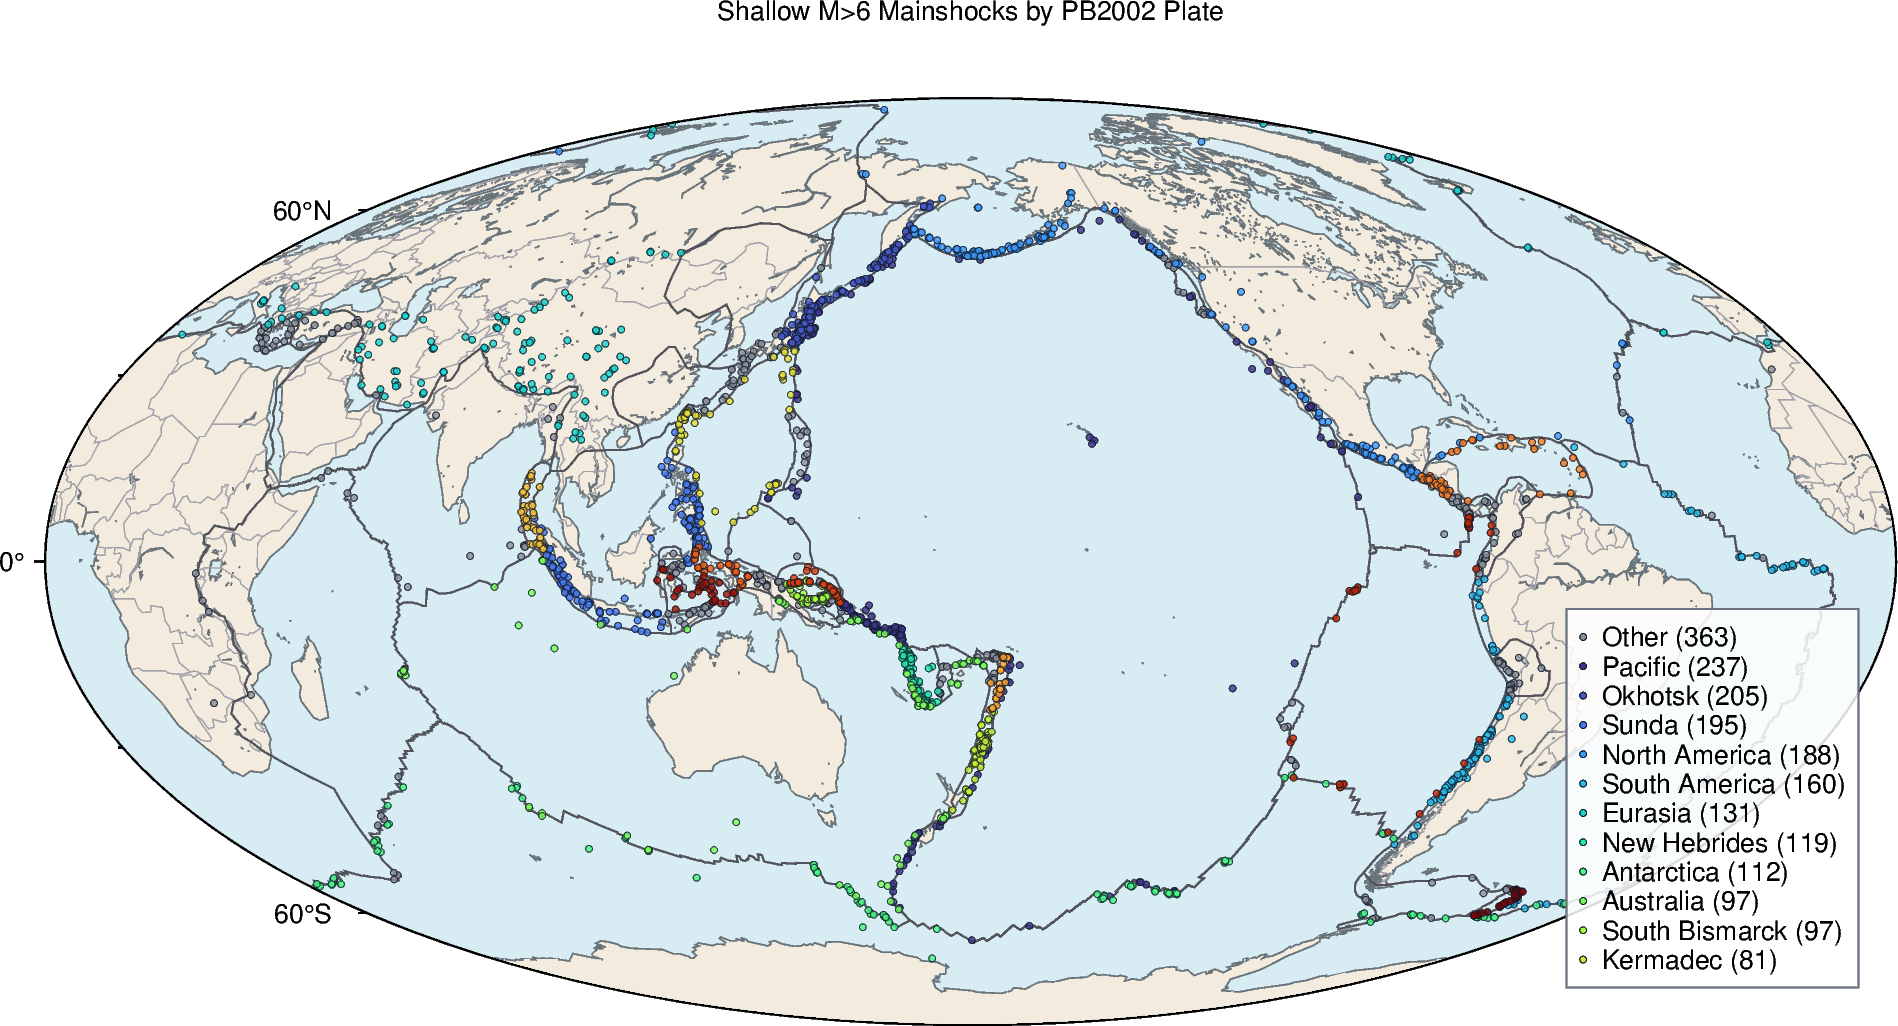

In [7]:
print(results['map_path'])
display(Image(filename=str(results['map_path'])))

## Mainshock Count Plot

/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/mainshock_plate_group_counts_depth_le_70_min30.png


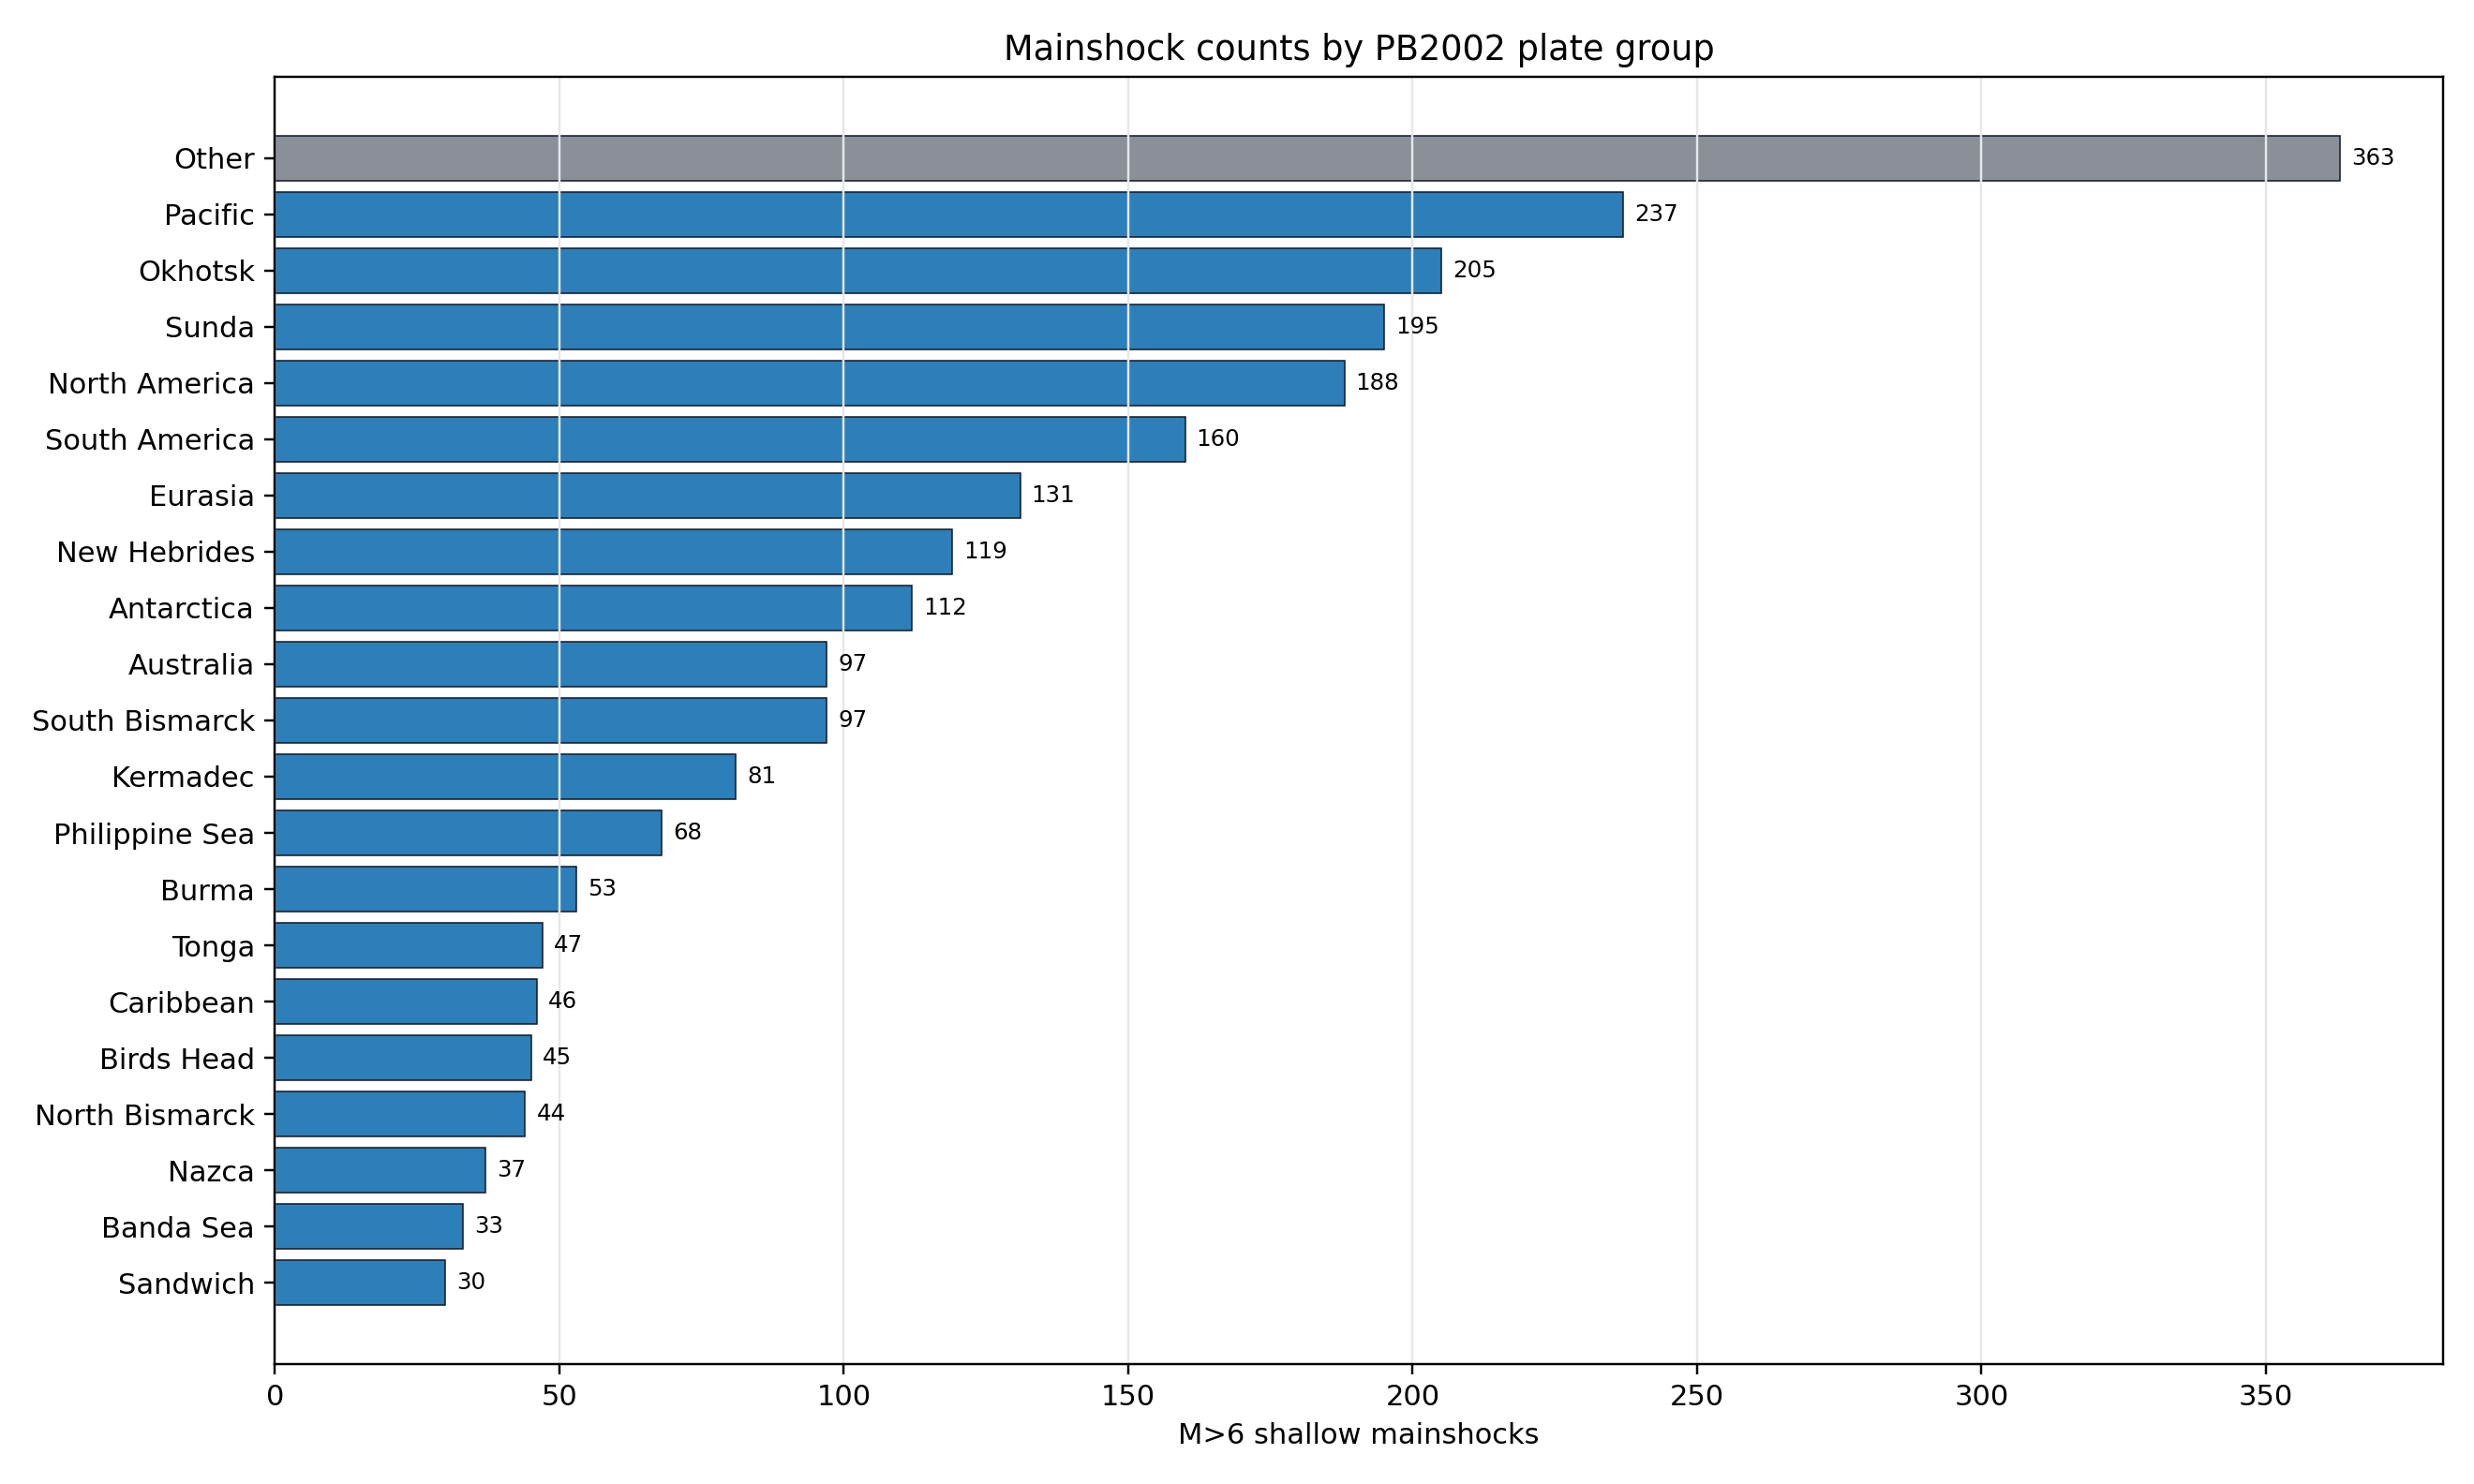

In [8]:
print(results['count_plot_path'])
display(Image(filename=str(results['count_plot_path'])))

## Saved Files

In [9]:
for key in [
    'assigned_parquet', 'assigned_csv', 'counts_csv', 'raw_counts_csv', 'twindow_summary_csv',
    'map_png', 'count_plot_png', 'delay_boxplot_png', 'mag_delta_boxplot_png',
    'delay_heatmap_png', 'mag_delta_heatmap_png',
]:
    path = Path(metadata[key])
    print(path, path.exists())
print(results['metadata_path'], results['metadata_path'].exists())

/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/mainshock_plate_assignments_depth_le_70_min30.parquet True
/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/mainshock_plate_assignments_depth_le_70_min30.csv True
/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/mainshock_plate_group_counts_depth_le_70_min30.csv True
/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/mainshock_plate_raw_counts_depth_le_70.csv True
/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/plate_twindow_delta_summary_depth_le_70_min30.csv True
/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/pygmt_mainshock_plate_groups_depth_le_70_min30.png True
/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_analysis/mainshock_plate_group_counts_depth_le_70_min30.png True
/Users/xusi/phdstudy/code/Prediction_contest/outputs/plate_mainshock_